Linear fit: y = 1.205987843183645x + 0.766785574172749
Linear MSE = 24.8845
Linear R-squared = 0.1381

Polynomial fit degree 3
Polynomial MSE = 21.1773
Polynomial R-squared = 0.2665

Polynomial fit is better.


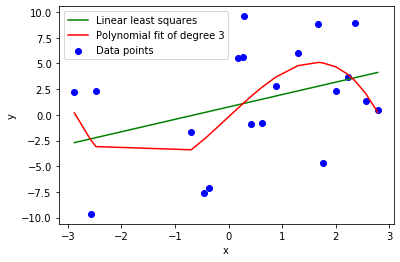

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def my_least_squares(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x2 = np.sum(x**2)
    m = ((n * sum_xy) - (sum_x * sum_y)) / ((n * sum_x2) - sum_x**2)
    b = (sum_y - (m * sum_x)) / n
    return m, b

def evaluate_fit(y, y_pred):
    mse = np.mean((y - y_pred)**2)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return mse, r_squared

np.random.seed(0)
x = np.random.uniform(-3, 3, 20)
y = np.random.uniform(-10, 10, 20)

idx = np.argsort(x)
x = x[idx]
y = y[idx]

m, b = my_least_squares(x, y)
y_line = m * x + b

degree = 3
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_poly = polynomial(x)

mse_line, r2_line = evaluate_fit(y, y_line)
mse_poly, r2_poly = evaluate_fit(y, y_poly)

print(f"Linear fit: y = {m}x + {b}")
print(f"Linear MSE = {mse_line:.4f}")
print(f"Linear R-squared = {r2_line:.4f}")

print(f"\nPolynomial fit degree {degree}")
print(f"Polynomial MSE = {mse_poly:.4f}")
print(f"Polynomial R-squared = {r2_poly:.4f}")

if mse_poly < mse_line and r2_poly > r2_line:
    print("\nPolynomial fit is better.")
elif mse_line < mse_poly and r2_line > r2_poly:
    print("Linear least squares fit is better.")
else:
    print("The metrics are mixed.")

plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_line, color='green', label='Linear least squares')
plt.plot(x, y_poly, color='red', label=f'Polynomial fit of degree {degree}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


Degree 1
Mean Squared Error: 24.8845
R-squared: 0.1381


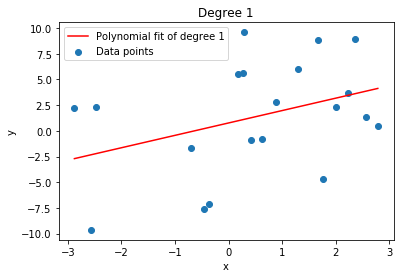

Degree 2
Mean Squared Error: 24.8845
R-squared: 0.1381


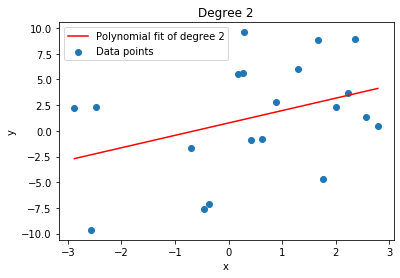

Degree 3
Mean Squared Error: 21.1773
R-squared: 0.2665


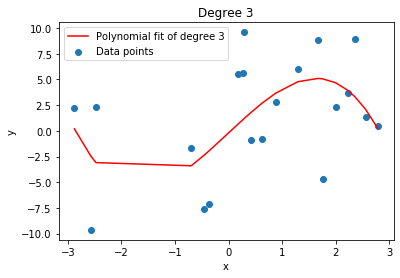

Degree 4
Mean Squared Error: 20.4617
R-squared: 0.2913


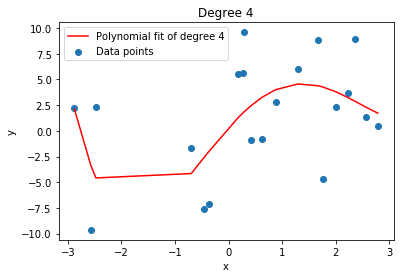

Degree 5
Mean Squared Error: 20.3964
R-squared: 0.2935


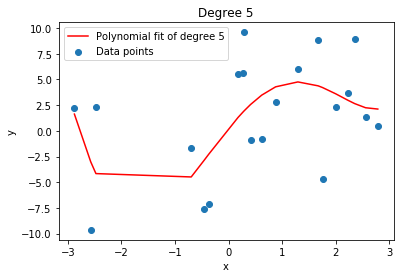

Degree 6
Mean Squared Error: 19.4014
R-squared: 0.3280


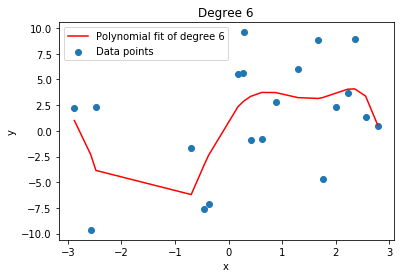

Degree 7
Mean Squared Error: 17.7040
R-squared: 0.3868


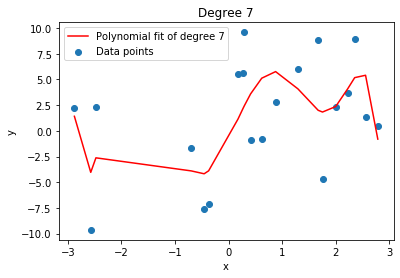

Degree 8
Mean Squared Error: 13.9147
R-squared: 0.5180


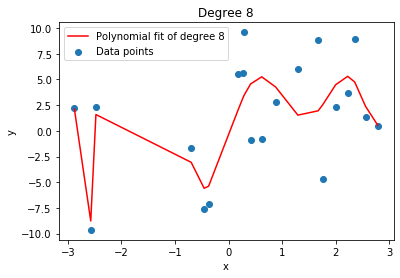

In [8]:
for degree in [1, 2, 3, 4, 5, 6, 7, 8]:
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(x)

    mse, r_squared = evaluate_fit(y, y_pred)

    print(f"Degree {degree}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R-squared: {r_squared:.4f}")

    plt.scatter(x, y, label='Data points')
    plt.plot(x, y_pred, color='red',label=f'Polynomial fit of degree {degree}')
    plt.title(f'Degree {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

Vandermonde Matrix: 
[[ 1.00000000e+00 -2.87868962e+00  8.28685390e+00 -2.38552803e+01]
 [ 1.00000000e+00 -2.57378365e+00  6.62436228e+00 -1.70496753e+01]
 [ 1.00000000e+00 -2.47722420e+00  6.13663975e+00 -1.52018325e+01]
 [ 1.00000000e+00 -6.99350887e-01  4.89091663e-01 -3.42046689e-01]
 [ 1.00000000e+00 -4.58071204e-01  2.09829228e-01 -9.61167271e-02]
 [ 1.00000000e+00 -3.74476732e-01  1.40232823e-01 -5.25139294e-02]
 [ 1.00000000e+00  1.73369519e-01  3.00569900e-02  5.21096588e-03]
 [ 1.00000000e+00  2.69299098e-01  7.25220042e-02  1.95301103e-02]
 [ 1.00000000e+00  2.92881024e-01  8.57792940e-02  2.51231274e-02]
 [ 1.00000000e+00  4.08267367e-01  1.66682243e-01  6.80509202e-02]
 [ 1.00000000e+00  6.16580256e-01  3.80171213e-01  2.34406064e-01]
 [ 1.00000000e+00  8.75364678e-01  7.66263320e-01  6.70759845e-01]
 [ 1.00000000e+00  1.29113620e+00  1.66703268e+00  2.15236624e+00]
 [ 1.00000000e+00  1.66894051e+00  2.78536241e+00  4.64860415e+00]
 [ 1.00000000e+00  1.75035023e+00  3.0637

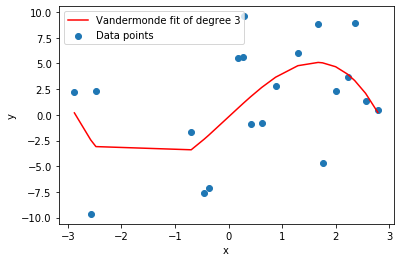

In [9]:
def vandermonde_matrix(x, degree):
    V = np.vander(x, N=degree+1, increasing=True)
    return V

degree = 3
V = vandermonde_matrix(x, degree)

vand_coefficients = np.linalg.lstsq(V, y, rcond=None)[0]

y_vand = np.zeros(len(x))
for i in range(len(vand_coefficients)):
    y_vand = y_vand + vand_coefficients[i] * x**i

mse_vand, r2_vand = evaluate_fit(y, y_vand)

print(f"Vandermonde Matrix: \n{V}")

print("\nVandermonde Coefficients: ", vand_coefficients)
print(f"Mean Squared Error: {mse_vand:.4f}")
print(f"R-squared: {r2_vand:.4f}")

plt.scatter(x, y, label='Data points')
plt.plot(x, y_vand, color='red', label=f'Vandermonde fit of degree {degree}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()